In [59]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
from pathlib import Path

from m3util.viz.layout import layout_fig
from m3util.viz.text import labelfigs
from sro_sto_plume import microscopy as mic
from m3util.viz.printing import printer
printing = printer(basepath='../figures/', fileformats=['png','svg','tif'], dpi=600)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_16459/1232346545.py:15: DeprecationWarning: The 'printer' class/function has been renamed to 'Printer'. Please update your code.
  printing = printer(basepath='../figures/', fileformats=['png','svg','tif'], dpi=600)


# Batch Roughness Comparison Across Area Exports

This notebook loads the full-area height maps exported as TXT files, flattens them (optional), and reports roughness in two ways:

1. Treat every pixel across all images in a folder as a single surface and compute Ra/Rq/Rz.
2. Compute the mean height of each image, then evaluate the variation of those means (image-to-image roughness).

Update the configuration below to point at the folders you would like to compare.

In [12]:
# --- Configuration ---
DATA_FOLDERS = [
    {"name": "sanded", "path": Path("../data/TargetMicroscopy/Scan2/sanded/"),  "loader": "datx", "pattern": "*.datx"},
    {"name": "G1", "path": Path("../data/TargetMicroscopy/Scan2/G1/"),  "loader": "datx", "pattern": "*.datx"},
    {"name": "G2", "path": Path("../data/TargetMicroscopy/Scan2/G2/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G3", "path": Path("../data/TargetMicroscopy/Scan2/G3/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G4", "path": Path("../data/TargetMicroscopy/Scan2/G4/"),   "loader": "datx", "pattern": "*.datx"},
    {"name": "G5", "path": Path("../data/TargetMicroscopy/Scan2/G5/"),   "loader": "datx", "pattern": "*.datx"},
]
PATTERN = "*.datx"           # default glob pattern
DETREND = False               # remove best-fit plane before computing roughness
ZERO_CENTER = False           # subtract per-image mean (after detrend)
HEIGHT_SCALE = 1e6           # meters -> micrometers
HEIGHT_UNIT = "µm"

In [13]:
def analyze_area_folder(folder_path: Path,
                          name: str | None = None,
                          *,
                          pattern: str = "*.txt",
                          loader: str = "txt",
                          dataset_keyword: str = "Surface",
                          detrend: bool = False,
                          zero_center: bool = False,
                          scale: float = 1.0,
                          unit: str = "µm"):
    '''Compute batch roughness metrics for all height maps in a folder.'''

    folder_path = Path(folder_path)
    files = sorted(folder_path.glob(pattern))
    if not files:
        raise ValueError(f"No files matching {pattern!r} in {folder_path}")

    loader_lower = loader.lower()
    if loader_lower == "txt":
        batch = mic.batch_roughness_from_txt(files, detrend=detrend, zero_center=zero_center)
    elif loader_lower == "datx":
        batch = mic.batch_roughness_from_datx(files,
                                             dataset_keyword=dataset_keyword,
                                             detrend=detrend,
                                             zero_center=zero_center)
    else:
        raise ValueError(f"Unsupported loader '{loader}'. Use 'txt' or 'datx'.")

    def scale_record(record: dict[str, float], *, keys: tuple[str, ...] = ("mean", "Ra", "Rq", "Rz")) -> dict[str, float]:
        rec = record.copy()
        for key in keys:
            if key in rec:
                rec[key] = rec[key] * scale
        return rec

    folder_label = name or folder_path.name

    global_stats = scale_record(batch["global_pixels"])
    global_stats.update({
        "folder": folder_label,
        "n_images": len(batch["per_image"]),
        "count": batch["global_pixels"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    mean_stats = scale_record(batch["image_mean_variation"])
    mean_stats.update({
        "folder": folder_label,
        "count": batch["image_mean_variation"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    rq_variation_stats = scale_record(
        batch["image_rq_variation"],
        keys=("mean", "std", "min", "max", "range"),
    )
    rq_variation_stats.update({
        "folder": folder_label,
        "count": batch["image_rq_variation"]["count"],
        "detrended": detrend,
        "zero_center": zero_center,
        "unit": unit,
    })

    per_image_rows = []
    for file, record in zip(files, batch["per_image"]):
        scaled = scale_record(record)
        scaled.update({
            "folder": folder_label,
            "path": str(file),
            "count": record["count"],
            "detrended": detrend,
            "zero_center": zero_center,
            "unit": unit,
        })
        per_image_rows.append(scaled)

    per_image_df = pd.DataFrame(per_image_rows)

    return global_stats, mean_stats, rq_variation_stats, per_image_df


## Compute batch roughness statistics

For each folder, the code below:

- loads all TXT files matching `PATTERN`,
- optionally detrends each map,
- records per-image roughness metrics,
- aggregates across all pixels,
- computes image-to-image variation (based on the mean height per image).

In [14]:
folder_summaries = []
mean_summaries = []
rq_variation_summaries = []
per_image_frames = []

for entry in DATA_FOLDERS:
    folder_name = entry["name"]
    folder_path = entry["path"]
    loader = entry.get("loader", "txt")
    dataset_keyword = entry.get("dataset_keyword", "Surface")
    pattern = entry.get("pattern", PATTERN)

    try:
        global_stats, mean_stats, rq_stats, per_image_df = analyze_area_folder(
            folder_path,
            name=folder_name,
            pattern=pattern,
            loader=loader,
            dataset_keyword=dataset_keyword,
            detrend=DETREND,
            zero_center=ZERO_CENTER,
            scale=HEIGHT_SCALE,
            unit=HEIGHT_UNIT,
        )
    except ValueError as exc:
        print(f"[WARN] {exc}")
        continue

    folder_summaries.append(global_stats)
    mean_summaries.append(mean_stats)
    rq_variation_summaries.append(rq_stats)
    per_image_frames.append(per_image_df)

if not folder_summaries:
    raise ValueError("No folders produced data. Check DATA_FOLDERS and PATTERN.")

folder_df = pd.DataFrame(folder_summaries).set_index("folder")
mean_df = pd.DataFrame(mean_summaries).set_index("folder")
rq_variation_df = pd.DataFrame(rq_variation_summaries).set_index("folder")
per_image_df = pd.concat(per_image_frames, ignore_index=True)

print("Global pixel-wise roughness (all pixels pooled)")
display(folder_df[["mean", "Ra", "Rq", "Rz", "count", "n_images", "detrended", "zero_center", "unit"]])

print("Per-image Rq variation (within folders)")
display(rq_variation_df[["mean", "std", "min", "max", "range", "cv", "count", "detrended", "zero_center", "unit"]])

print("Image-to-image variation (based on image means)")
display(mean_df[["mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])

print("Per-image roughness metrics")
display(per_image_df[["folder", "path", "mean", "Ra", "Rq", "Rz", "count", "detrended", "zero_center", "unit"]])


Global pixel-wise roughness (all pixels pooled)


,mean,Ra,Rq,Rz,count,n_images,detrended,zero_center,unit
folder,,,,,,,,,
sanded,50.603051,6.750516,8.349822,68.403026,4797410,5,False,False,µm
G1,52.724851,5.689439,6.973697,99.321171,3264594,4,False,False,µm
G2,49.766414,6.786993,8.314735,99.762961,3479683,5,False,False,µm
G3,49.578595,5.251969,6.574261,98.553100,2353534,4,False,False,µm
G4,49.437793,5.442985,6.723045,97.342273,2689105,4,False,False,µm
G5,52.711941,6.579916,8.130951,98.090550,2775769,4,False,False,µm


Per-image Rq variation (within folders)


,mean,std,min,max,range,cv,count,detrended,zero_center,unit
folder,,,,,,,,,,
sanded,7.030026,1.329747,5.386655,8.952341,3.565686,0.189152,5,False,False,µm
G1,6.901704,0.829705,5.581450,7.769922,2.188472,0.120217,4,False,False,µm
G2,7.047319,0.540399,6.283902,7.729875,1.445973,0.076681,5,False,False,µm
G3,6.218629,0.443063,5.681770,6.880894,1.199124,0.071248,4,False,False,µm
G4,6.456054,0.434307,5.955057,7.119800,1.164744,0.067271,4,False,False,µm
G5,7.933292,0.463440,7.365984,8.565597,1.199614,0.058417,4,False,False,µm


Image-to-image variation (based on image means)


,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
folder,,,,,,,,
sanded,50.578934,3.837969,4.322108,11.931911,5,False,False,µm
G1,52.732780,0.797433,0.822560,1.951473,4,False,False,µm
G2,49.575277,3.580060,4.480138,13.393397,5,False,False,µm
G3,49.562679,1.711238,2.073469,5.564441,4,False,False,µm
G4,49.426290,1.727950,1.859364,4.828855,4,False,False,µm
G5,52.708536,1.594204,1.713539,4.361851,4,False,False,µm


Per-image roughness metrics


,folder,path,mean,Ra,Rq,Rz,count,detrended,zero_center,unit
0,sanded,../data/TargetMicroscopy/Scan2/sanded/s1.datx,51.345291,4.273773,5.386655,43.598751,971868,False,False,µm
1,sanded,../data/TargetMicroscopy/Scan2/sanded/s2.datx,44.742883,4.704060,5.825871,57.101105,943395,False,False,µm
2,sanded,../data/TargetMicroscopy/Scan2/sanded/s3.datx,46.820061,7.505029,8.952341,60.706878,954014,False,False,µm
3,sanded,../data/TargetMicroscopy/Scan2/sanded/s4.datx,53.311639,6.798546,8.025161,49.314161,978549,False,False,µm
4,sanded,../data/TargetMicroscopy/Scan2/sanded/s6.datx,56.674795,5.815521,6.960102,51.616192,949584,False,False,µm
5,G1,../data/TargetMicroscopy/Scan2/G1/s1.datx,51.662634,5.686941,6.849692,92.778080,836629,False,False,µm
6,G1,../data/TargetMicroscopy/Scan2/G1/s4.datx,52.208060,6.340901,7.769922,84.165883,801324,False,False,µm
7,G1,../data/TargetMicroscopy/Scan2/G1/s5.datx,53.614107,6.129036,7.405754,91.238610,770191,False,False,µm
8,G1,../data/TargetMicroscopy/Scan2/G1/s8.datx,53.446319,4.583453,5.581450,78.845310,856450,False,False,µm
9,G2,../data/TargetMicroscopy/Scan2/G2/s2.datx,56.713298,5.065815,6.283902,90.068571,710137,False,False,µm


## Visual comparisons

Bar plots and strip plots make it easier to compare roughness across folders.

In [26]:
colors

((0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354))

../figures/FigureS1-TargetMicroscopy.png
../figures/FigureS1-TargetMicroscopy.svg
../figures/FigureS1-TargetMicroscopy.tif


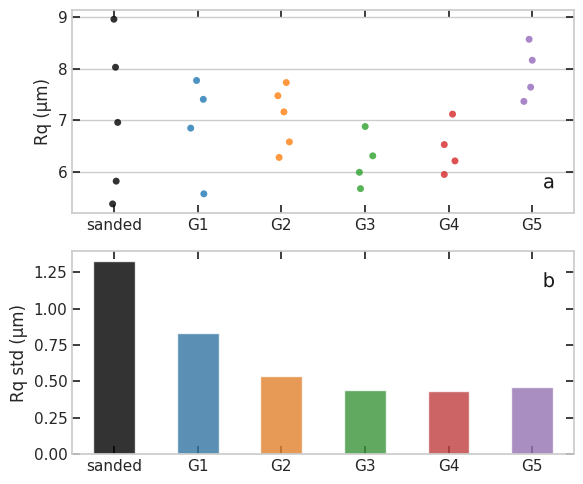

In [60]:
base = colormaps.get_cmap("tab10").colors[:5]
colors = [(0, 0, 0), *base]
order = folder_df.index.tolist()

fig, axes = layout_fig(2, 1, figsize=(6, 5), layout='tight')

sns.stripplot(data=per_image_df, x="folder", y="Rq", hue="folder", order=order, palette=dict(zip(order, colors)), ax=axes[0], alpha=0.8)
axes[0].set_ylabel(f"Rq ({HEIGHT_UNIT})")
axes[0].tick_params( axis="both", which="both", direction="in", top=True, bottom=True, left=True, right=True, labelbottom=True, labelleft=True)
axes[0].set_xlabel("")
labelfigs(axes[0], 0, style='bw', loc='br', inset_fraction=(0.15, 0.05), size=14)

sns.barplot(x=rq_variation_df.index, y="std", hue="folder", data=rq_variation_df.reset_index(), ax=axes[1], order=order, palette=dict(zip(order, colors)), alpha=0.8, width=0.5)
axes[1].set_ylabel(f"Rq std ({HEIGHT_UNIT})")
axes[1].grid(False, axis="y")        # make sure no horizontal lines remain
axes[1].tick_params( axis="both", which="both", direction="in", top=True, bottom=True, left=True, right=True, labelbottom=True, labelleft=True)
axes[1].set_xlabel("")
labelfigs(axes[1], 1, style='bw', loc='tr', inset_fraction=(0.15, 0.05), size=14)

printing.savefig(fig, 'FigureS1-TargetMicroscopy')
plt.show()

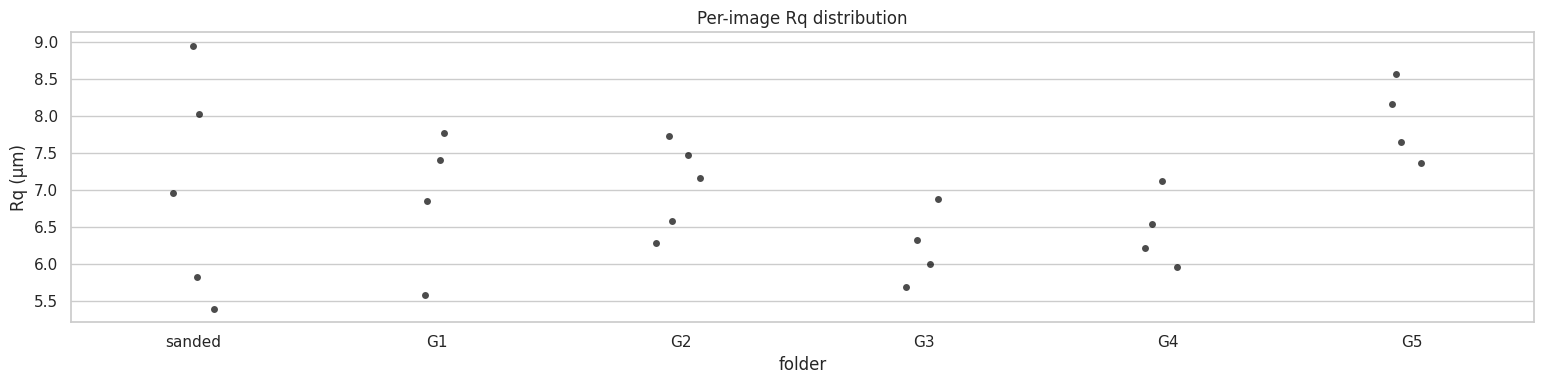

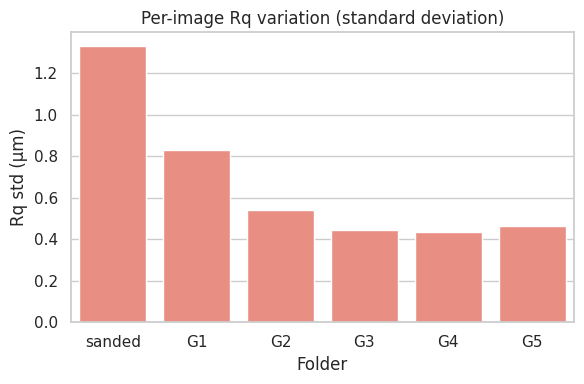

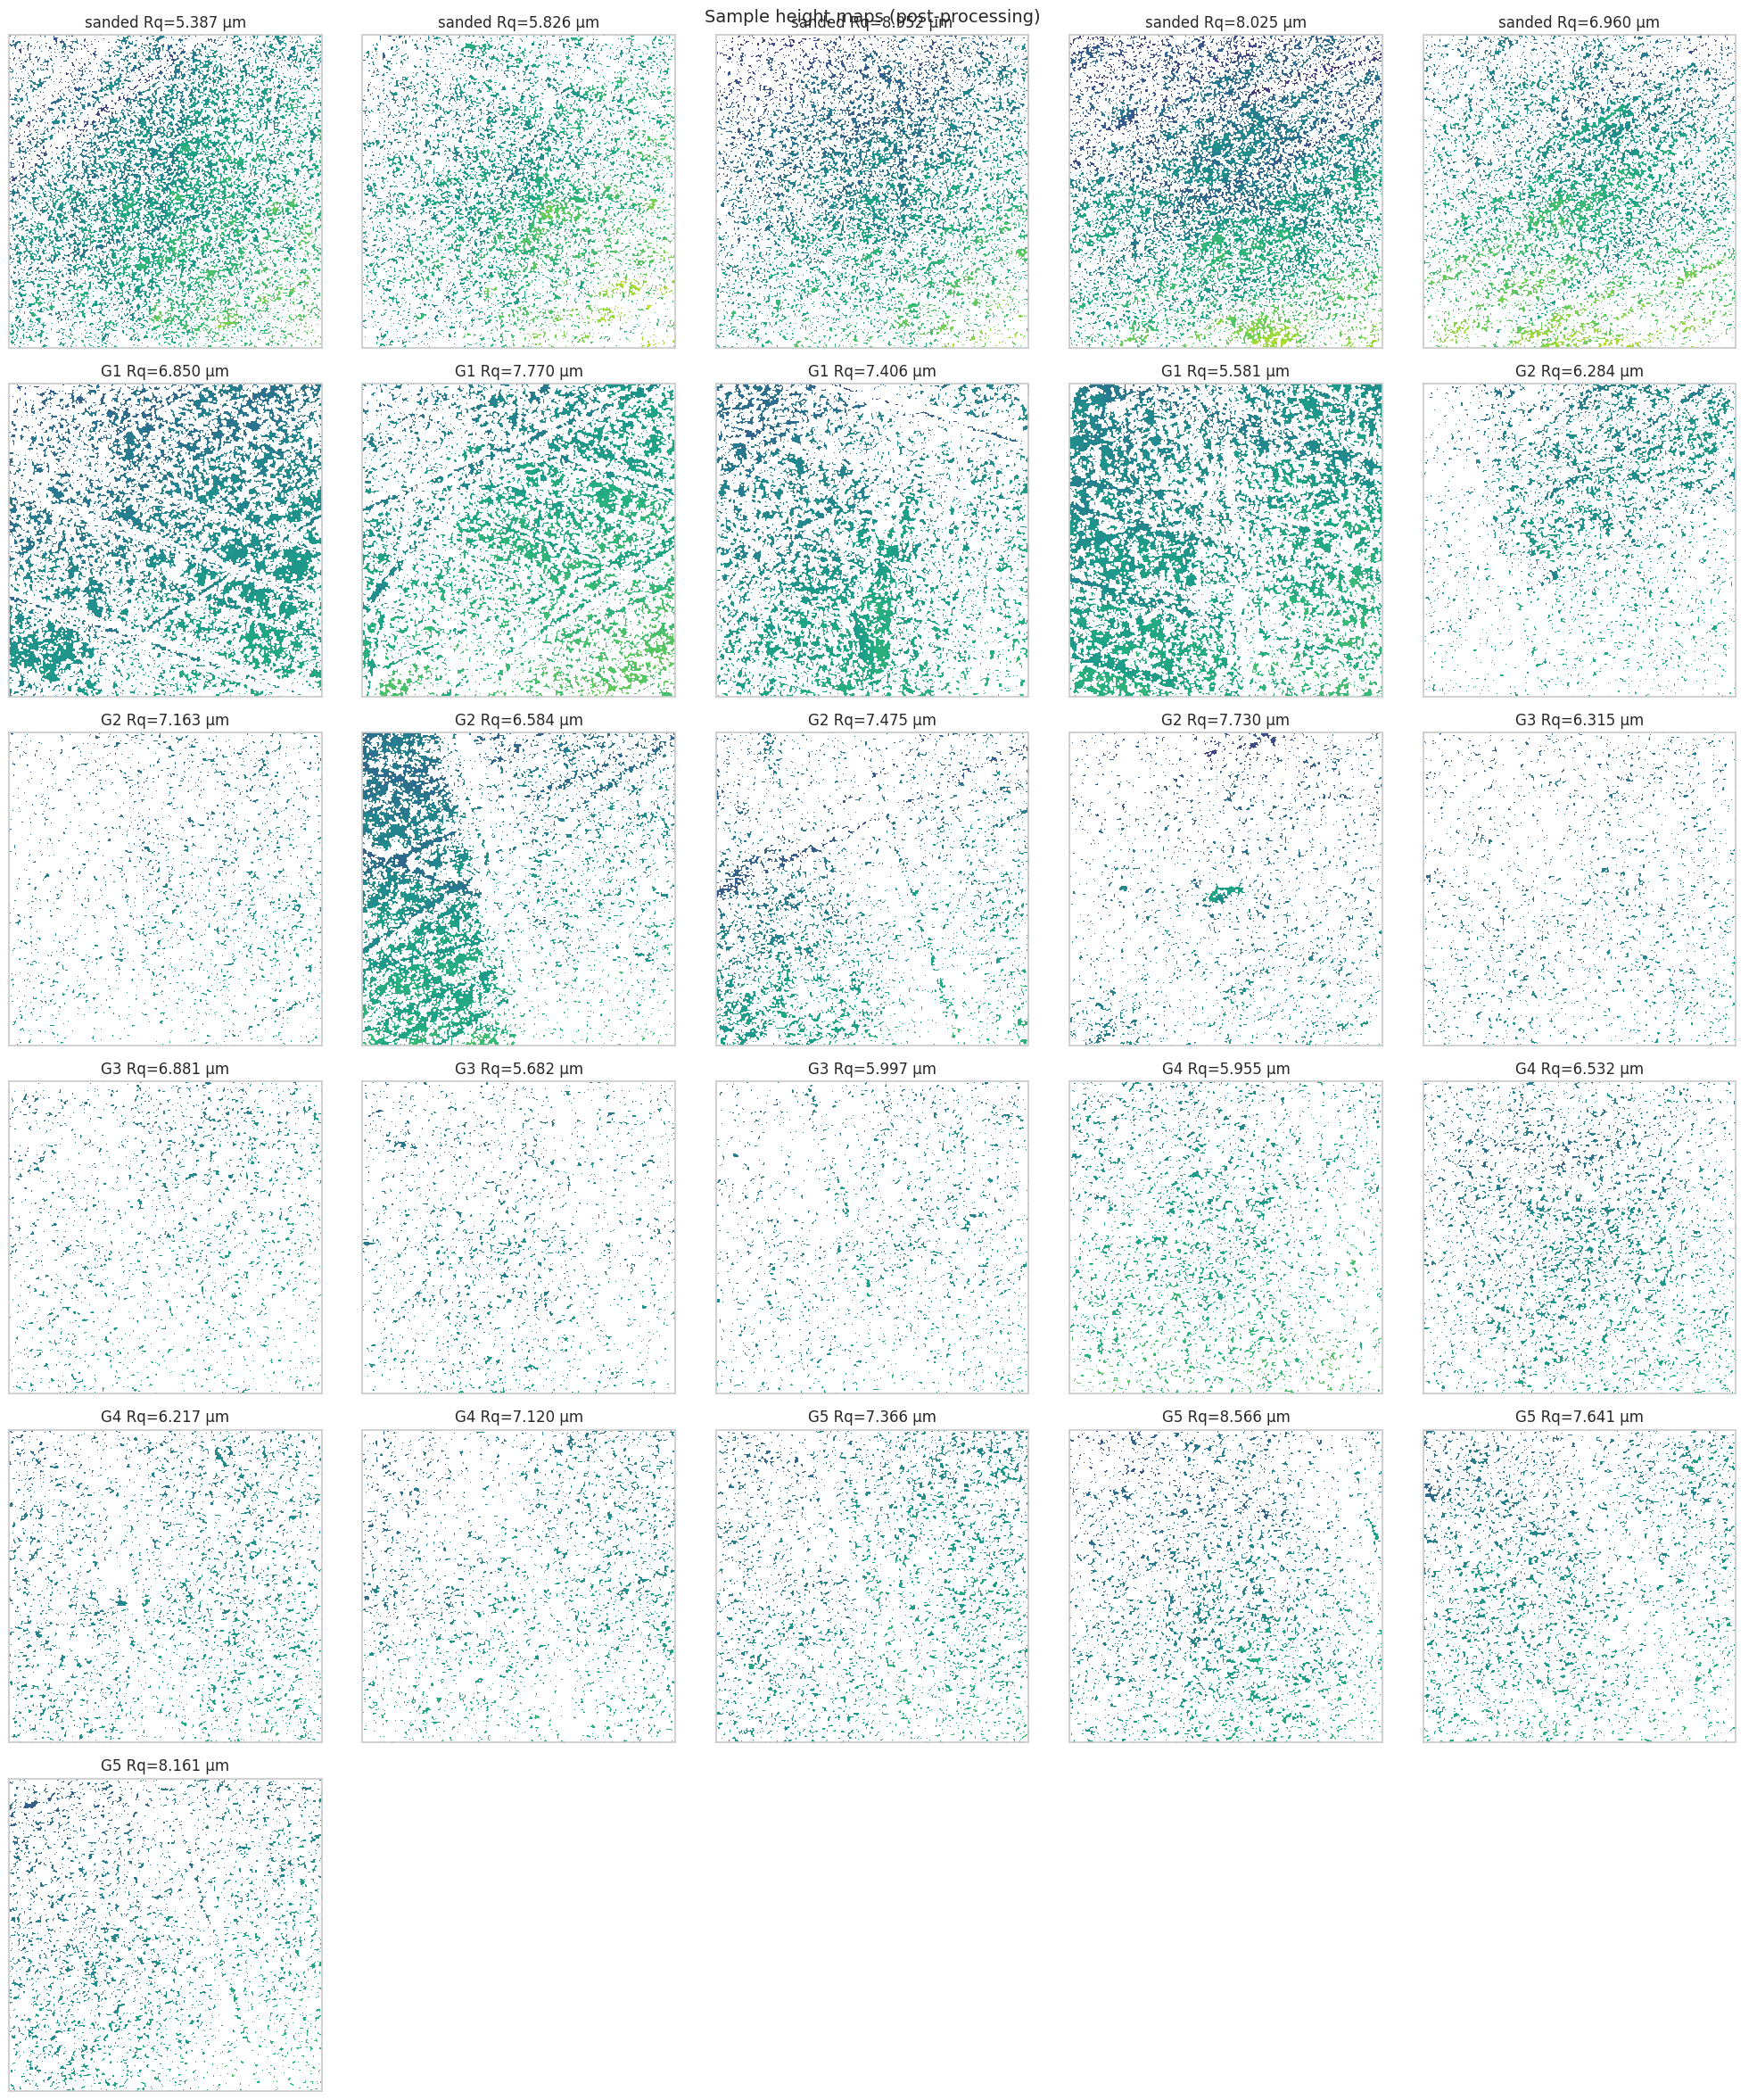

In [ ]:
fig, ax = plt.subplots(figsize=(max(6, len(per_image_df) * 0.6), 4))
sns.stripplot(data=per_image_df, x="folder", y="Rq", ax=ax, color="black", alpha=0.7)
ax.set_ylabel(f"Rq ({HEIGHT_UNIT})")
ax.set_title("Per-image Rq distribution")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(max(6, len(rq_variation_df) * 1.0), 4))
sns.barplot(x=rq_variation_df.index, y="std", data=rq_variation_df.reset_index(), ax=ax, color="salmon")
ax.set_ylabel(f"Rq std ({HEIGHT_UNIT})")
ax.set_xlabel("Folder")
ax.set_title("Per-image Rq variation (standard deviation)")
fig.tight_layout()
plt.show()

In [ ]:

# Thumbnail visualization
n_images = len(per_image_df)
if n_images:
    ncols = min(5, n_images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes[n_images:]:
        ax.axis('off')

    for ax, row in zip(axes, per_image_df.itertuples()):
        path = Path(row.path)
        loader = next((entry.get('loader', 'txt').lower() for entry in DATA_FOLDERS
                       if entry['name'] == row.folder), 'txt')

        if loader == 'datx':
            data = mic.load_datx_height_map(path)
        else:
            data = mic.load_height_txt(path)

        if DETREND:
            data = mic._detrend_plane(data)
        if ZERO_CENTER:
            mean_val = np.nanmean(data)
            if np.isfinite(mean_val):
                data = data - mean_val

        ax.imshow(data, cmap='viridis')
        ax.set_title(f"{row.folder} Rq={row.Rq:.3f} {HEIGHT_UNIT}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle('Sample height maps (post-processing)', fontsize=14)
    fig.tight_layout()

plt.show()
